# 🌲 Módulo 01: Machine Learning Estadístico & Optimización Convexa
## Capítulo 3: De los Árboles de Decisión a Gradient Boosted Trees (XGBoost From Scratch)

> *"Mientras que las redes neuronales rotan y deforman el espacio mediante composiciones suaves, los árboles de decisión lo fracturan con hiperplanos ortogonales. Y cuando sumamos árboles optimizando derivadas de segundo orden (Taylor), obtenemos el rey indiscutible de los datos tabulares: Gradient Boosting."*

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mcarbonell/algo-to-ai/blob/main/notebooks/01_classical_ml/03_decision_trees_to_xgboost.ipynb)

---

### ⚙️ Inicialización del Entorno
Cargamos las librerías necesarias y fijamos semillas para asegurar reproducibilidad.

In [1]:
# !pip install -q numpy matplotlib scikit-learn xgboost
from typing import Optional, List, Tuple
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
print("✅ Entorno listo para Árboles y Gradient Boosted Trees")

✅ Entorno listo para Árboles y Gradient Boosted Trees


---

## 1. 📜 Contexto Histórico y Proceso de Descubrimiento

### El Nacimiento de CART (1984): Intuitivos pero Frágiles
En 1984, cuatro estadísticos legendarios —**Leo Breiman, Jerome Friedman, Richard Olshen y Charles Stone**— publicaron el libro seminal *Classification and Regression Trees (CART)*.

Los árboles de decisión fascinaron a los programadores porque se sentían como código nativo: una cascada jerárquica de sentencias `if / else`. Sin embargo, tenían un fallo mortal de varianza:
> **El problema de la inestabilidad:** Cambiar o añadir una sola muestra de datos podía alterar la división de la raíz y reestructurar por completo todo el árbol, cambiando drásticamente todas las predicciones.

### El Giro de Tuerca: De Modelos Solitarios a Ensembles
Durante los años 90, la comunidad se dio cuenta de que combinar muchos modelos débiles (*weak learners*) producía resultados sobrehumanos:
1. **Bagging & Random Forests (Breiman, 1996, 2001):** Entrenar cientos de árboles profundos en paralelo sobre subconjuntos aleatorios de datos y promediar sus predicciones. Esto redujo la varianza sin aumentar el sesgo gracias a la ley de los grandes números.
2. **Boosting y AdaBoost (Freund & Schapire, 1996):** En lugar de entrenar en paralelo, entrenar árboles secuencialmente, obligando a cada nuevo árbol a concentrarse en los errores cometidos por los árboles anteriores.

### La Gran Epifanía de Friedman: Descenso de Gradiente en el Espacio de Funciones (2001)
En 2001, **Jerome Friedman** descubrió algo revolucionario: AdaBoost no era un truco heurístico, sino una instancia particular de **Descenso de Gradiente en el Espacio de Funciones (Gradient Boosting Machine - GBM)**. Cada nuevo árbol que añadimos no es más que un paso de gradiente negativo que predice los residuos de la función de pérdida.

### La Revolución de Tianqi Chen: XGBoost (2016)
Hacia 2014-2016, las competiciones de Kaggle y los sistemas de recomendación industriales fueron arrasados por una nueva librería de código abierto creada por **Tianqi Chen y Carlos Guestrin**: **XGBoost (Extreme Gradient Boosting)**.

Chen introdujo una formulación matemática formidable:
* En lugar de usar solo gradientes de primer orden ($g_i$), aplicó una **expansión en serie de Taylor de segundo orden** (incluyendo el Hessiano o curvatura $h_i = rac{\partial^2 \mathcal{L}}{\partial \hat{y}_i^2}$).
* Añadió una **regularización formal de la estructura del árbol** ($\lambda$ para la magnitud de las hojas y $\gamma$ para el número de hojas).
* Esto permitió derivar en **forma cerrada exacta** el peso óptimo de cada hoja y la ganancia de cada división (*split gain*), logrando velocidades de entrenamiento órdenes de magnitud más rápidas y una resistencia al sobreajuste nunca vista.

---

## 2. 🧠 Intuición Geométrica y Mecánica (Mentalidad de Algoritmista)

### A. Particiones Ortogonales vs Transformaciones Suaves
¿En qué se diferencia fundamentalmente un árbol de una red neuronal o regresión logística?
* Las **redes neuronales** trazan combinaciones lineales $w^T x + b = 0$ que rotan en cualquier ángulo del espacio continuo.
* Los **árboles de decisión** solo pueden trazar cortes **estrictamente perpendiculares a los ejes de coordenadas** ($x_j \le 	ext{umbral}$).

Visualicemos cómo un árbol de decisión va partiendo el plano cartesiano en cuadrantes ortogonales:

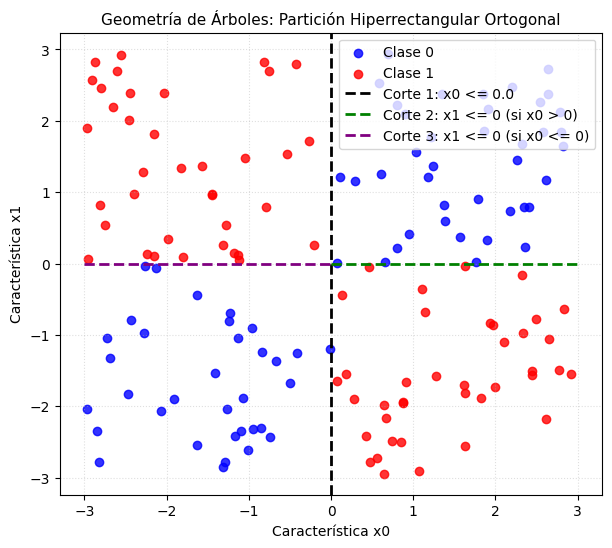

In [2]:
# Generar datos no lineales tipo 'tablero' / cuadrantes
np.random.seed(42)
X_demo = np.random.uniform(-3, 3, (150, 2))
# Función de cuadrantes no lineal
y_demo = ((X_demo[:, 0] > 0) ^ (X_demo[:, 1] > 0)).astype(int)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(X_demo[y_demo == 0, 0], X_demo[y_demo == 0, 1], color='blue', label='Clase 0', alpha=0.8)
ax.scatter(X_demo[y_demo == 1, 0], X_demo[y_demo == 1, 1], color='red', label='Clase 1', alpha=0.8)

# Ilustración de divisiones ortogonales sucesivas de un árbol
ax.axvline(x=0.0, color='black', linestyle='--', linewidth=2, label='Corte 1: x0 <= 0.0')
ax.plot([0, 3], [0, 0], color='green', linestyle='--', linewidth=2, label='Corte 2: x1 <= 0 (si x0 > 0)')
ax.plot([-3, 0], [0, 0], color='purple', linestyle='--', linewidth=2, label='Corte 3: x1 <= 0 (si x0 <= 0)')

ax.set_title("Geometría de Árboles: Partición Hiperrectangular Ortogonal", fontsize=11)
ax.set_xlabel("Característica x0")
ax.set_ylabel("Característica x1")
ax.grid(True, linestyle=':', alpha=0.4)
ax.legend(loc='upper right')
plt.show()

### B. La Matemática de Tianqi Chen (XGBoost) en 3 Ecuaciones Elegantes

Sea un conjunto de datos $\{(x_i, y_i)\}_{i=1}^n$ y una función de pérdida diferenciable $\mathcal{L}(y_i, \hat{y}_i)$. En el paso $t$, queremos añadir un árbol $f_t(x)$ tal que la nueva predicción sea $\hat{y}_i^{(t)} = \hat{y}_i^{(t-1)} + f_t(x_i)$.

#### 1. Aproximación de Taylor de 2º Orden
$$\mathcal{L}^{(t)} \approx \sum_{i=1}^n \left[ \mathcal{L}(y_i, \hat{y}_i^{(t-1)}) + g_i f_t(x_i) + rac{1}{2} h_i f_t^2(x_i) 
ight] + \gamma T + rac{1}{2}\lambda \sum_{j=1}^T w_j^2$$
Donde:
* $g_i = rac{\partial \mathcal{L}(y_i, \hat{y}_i^{(t-1)})}{\partial \hat{y}_i^{(t-1)}}$ (Gradiente de primer orden)
* $h_i = rac{\partial^2 \mathcal{L}(y_i, \hat{y}_i^{(t-1)})}{\partial (\hat{y}_i^{(t-1)})^2}$ (Hessiano / Curvatura de segundo orden)
* $T$ es el número de hojas del árbol, y $w_j$ es el valor de salida (peso) asignado a la hoja $j$.

#### 2. Peso Óptimo de una Hoja (Closed-Form Leaf Weight)
Si agrupamos las muestras que caen en la hoja $j$ como el conjunto de índices $I_j = \{i : q(x_i) = j\}$, derivando respecto a $w_j$ e igualando a cero obtenemos:

$$w_j^* = - rac{\sum_{i \in I_j} g_i}{\sum_{i \in I_j} h_i + \lambda}$$

> **Intuición:** El peso es proporcional a la suma de gradientes negativos, amortiguado por la curvatura total más la regularización $\lambda$. ¡Si una hoja tiene pocas muestras o curvatura pequeña, $\lambda$ evita que el peso explote!

#### 3. Ganancia de División (The XGBoost Split Gain Formula)
Para decidir si dividir un nodo padre $P$ en dos nodos hijos Izquierdo ($L$) y Derecho ($R$):

$$	ext{Gain} = rac{1}{2} \left[ rac{\left(\sum_{i \in I_L} g_i
ight)^2}{\sum_{i \in I_L} h_i + \lambda} + rac{\left(\sum_{i \in I_R} g_i
ight)^2}{\sum_{i \in I_R} h_i + \lambda} - rac{\left(\sum_{i \in I_P} g_i
ight)^2}{\sum_{i \in I_P} h_i + \lambda} 
ight] - \gamma$$

Si $	ext{Gain} > 0$, el corte mejora la pérdida más allá del coste de complejidad $\gamma$. Si es negativo, el árbol se poda automáticamente.

---

## 3. 🛠️ Implementación "From Scratch" (Primeros Principios)

Vamos a implementar un motor **XGBoost completo from-scratch** en Python y NumPy puros, utilizando la formulación exacta de Tianqi Chen.

In [3]:
class XGBoostNode:
    """Nodo del árbol de decisión de XGBoost con pesos calculados analíticamente."""
    def __init__(self, depth: int = 0):
        self.depth = depth
        self.is_leaf = True
        self.weight: float = 0.0
        self.split_feature: Optional[int] = None
        self.split_threshold: Optional[float] = None
        self.left: Optional['XGBoostNode'] = None
        self.right: Optional['XGBoostNode'] = None


class MiniXGBoostTree:
    """
    Árbol individual de XGBoost entrenado usando gradientes (g) y hessianos (h)
    mediante la fórmula de ganancia de división de Tianqi Chen.
    """
    def __init__(self, max_depth: int = 3, reg_lambda: float = 1.0, min_child_weight: float = 1.0, gamma: float = 0.0):
        self.max_depth = max_depth
        self.reg_lambda = reg_lambda
        self.min_child_weight = min_child_weight
        self.gamma = gamma
        self.root = XGBoostNode(depth=0)

    def _compute_leaf_weight(self, g: np.ndarray, h: np.ndarray) -> float:
        # w* = - G / (H + lambda)
        return - np.sum(g) / (np.sum(h) + self.reg_lambda)

    def _compute_gain(self, G: float, H: float) -> float:
        # Score = G^2 / (H + lambda)
        return (G ** 2) / (H + self.reg_lambda)

    def fit(self, X: np.ndarray, g: np.ndarray, h: np.ndarray):
        self._build_node(self.root, X, g, h)
        return self

    def _build_node(self, node: XGBoostNode, X: np.ndarray, g: np.ndarray, h: np.ndarray):
        # Calcular peso óptimo de la hoja actual
        node.weight = self._compute_leaf_weight(g, h)
        
        # Criterios de parada: profundidad máxima o insuficientes muestras (Hessiano pequeño)
        if node.depth >= self.max_depth or np.sum(h) < self.min_child_weight:
            node.is_leaf = True
            return

        m, d = X.shape
        best_gain = 0.0
        best_feature = None
        best_threshold = None
        
        G_parent = np.sum(g)
        H_parent = np.sum(h)
        score_parent = self._compute_gain(G_parent, H_parent)

        # Búsqueda voraz del mejor corte (Exact Greedy Split Finder)
        for feat in range(d):
            x_col = X[:, feat]
            # Considerar percentiles o valores únicos como umbrales candidatos
            thresholds = np.unique(x_col)
            if len(thresholds) <= 1:
                continue
                
            for t in thresholds[:-1]:
                left_mask = x_col <= t
                right_mask = ~left_mask
                
                H_left = np.sum(h[left_mask])
                H_right = np.sum(h[right_mask])
                
                # Restricción de peso mínimo en el hijo
                if H_left < self.min_child_weight or H_right < self.min_child_weight:
                    continue
                    
                G_left = np.sum(g[left_mask])
                G_right = np.sum(g[right_mask])
                
                # Fórmula de ganancia de Chen
                gain = 0.5 * (self._compute_gain(G_left, H_left) + 
                              self._compute_gain(G_right, H_right) - 
                              score_parent) - self.gamma
                
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feat
                    best_threshold = t

        # Si encontramos una división con ganancia positiva, dividimos el nodo
        if best_gain > 0.0 and best_feature is not None:
            node.is_leaf = False
            node.split_feature = best_feature
            node.split_threshold = best_threshold
            
            left_mask = X[:, best_feature] <= best_threshold
            right_mask = ~left_mask
            
            node.left = XGBoostNode(depth=node.depth + 1)
            node.right = XGBoostNode(depth=node.depth + 1)
            
            self._build_node(node.left, X[left_mask], g[left_mask], h[left_mask])
            self._build_node(node.right, X[right_mask], g[right_mask], h[right_mask])

    def predict_row(self, node: XGBoostNode, x: np.ndarray) -> float:
        if node.is_leaf:
            return node.weight
        if x[node.split_feature] <= node.split_threshold:
            return self.predict_row(node.left, x)
        return self.predict_row(node.right, x)

    def predict(self, X: np.ndarray) -> np.ndarray:
        return np.array([self.predict_row(self.root, row) for row in X])

print("✅ MiniXGBoostTree definido correctamente")

✅ MiniXGBoostTree definido correctamente


### Construyendo el Ensemble Completo: `MiniXGBoostRegressor`

In [4]:
class MiniXGBoostRegressor:
    """
    Ensemble de Gradient Boosting completo from-scratch usando árboles de 2º orden.
    """
    def __init__(
        self,
        n_estimators: int = 30,
        learning_rate: float = 0.1,
        max_depth: int = 3,
        reg_lambda: float = 1.0,
        gamma: float = 0.0
    ):
        self.n_estimators = n_estimators
        self.lr = learning_rate
        self.max_depth = max_depth
        self.reg_lambda = reg_lambda
        self.gamma = gamma
        self.base_pred: float = 0.0
        self.trees: List[MiniXGBoostTree] = []
        self.train_losses: List[float] = []

    def fit(self, X: np.ndarray, y: np.ndarray):
        m = len(y)
        # Predicción base inicial: la media de las etiquetas y
        self.base_pred = float(np.mean(y))
        y_pred = np.full(m, self.base_pred)
        self.trees = []
        self.train_losses = []

        for t in range(self.n_estimators):
            # 1. Calcular Gradiente y Hessiano de la pérdida MSE: L = 1/2 (y_hat - y)^2
            # g_i = y_pred - y
            # h_i = 1.0 (constante para MSE)
            g = y_pred - y
            h = np.ones(m)
            
            loss = 0.5 * np.mean(g ** 2)
            self.train_losses.append(loss)
            
            # 2. Ajustar un nuevo árbol de segundo orden a g y h
            tree = MiniXGBoostTree(
                max_depth=self.max_depth,
                reg_lambda=self.reg_lambda,
                gamma=self.gamma
            )
            tree.fit(X, g, h)
            self.trees.append(tree)
            
            # 3. Actualizar predicciones con factor de aprendizaje (Shrinkage)
            y_pred += self.lr * tree.predict(X)
            
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        y_pred = np.full(len(X), self.base_pred)
        for tree in self.trees:
            y_pred += self.lr * tree.predict(X)
        return y_pred

print("✅ MiniXGBoostRegressor definido correctamente")

✅ MiniXGBoostRegressor definido correctamente


### Demostración: Ajuste de una Función No Lineal Compleja (Onda Senoidal Ruidosa)

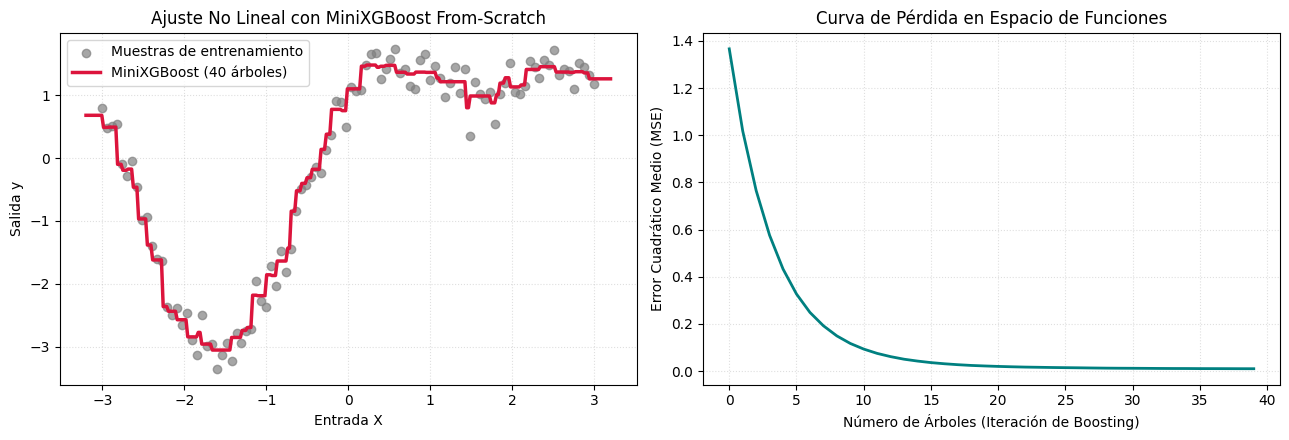

In [5]:
# Generar datos de una función sinusoidal no lineal con ruido
np.random.seed(42)
X_sine = np.linspace(-3, 3, 100).reshape(-1, 1)
y_sine = np.sin(X_sine[:, 0]) * 2.0 + np.cos(X_sine[:, 0] * 2) + np.random.randn(100) * 0.25

# Entrenar nuestro MiniXGBoost
model_xgb = MiniXGBoostRegressor(n_estimators=40, learning_rate=0.15, max_depth=3, reg_lambda=1.0)
model_xgb.fit(X_sine, y_sine)

# Visualizar ajuste y curva de convergencia
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Panel 1: Ajuste del modelo
X_grid = np.linspace(-3.2, 3.2, 300).reshape(-1, 1)
ax1.scatter(X_sine, y_sine, color='gray', alpha=0.7, label='Muestras de entrenamiento')
ax1.plot(X_grid, model_xgb.predict(X_grid), 'crimson', linewidth=2.5, label='MiniXGBoost (40 árboles)')
ax1.set_title("Ajuste No Lineal con MiniXGBoost From-Scratch")
ax1.set_xlabel("Entrada X")
ax1.set_ylabel("Salida y")
ax1.grid(True, linestyle=':', alpha=0.4)
ax1.legend()

# Panel 2: Descenso de la Pérdida de Entrenamiento
ax2.plot(model_xgb.train_losses, 'teal', linewidth=2)
ax2.set_title("Curva de Pérdida en Espacio de Funciones")
ax2.set_xlabel("Número de Árboles (Iteración de Boosting)")
ax2.set_ylabel("Error Cuadrático Medio (MSE)")
ax2.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

---

## 4. ⚡ Transición a XGBoost Oficial y por qué sigue Ganando en Datos Tabulares

A pesar del auge de los Transformers y las Redes Neuronales Profundas, **los Gradient Boosted Trees siguen dominando los benchmarks en datos tabulares**.

Un famoso estudio de NeurIPS 2022 (*Grinsztajn et al.*) evaluó 45 datasets del mundo real y demostró que librerías como XGBoost y LightGBM superan sistemáticamente a arquitecturas como TabNet, FT-Transformer y ResNets tabulares, por tres razones computacionales clave:
1. **Invarianza a transformaciones monótonas:** Dividir en $x_j \le t$ no se ve afectado si aplicas $\log(x_j)$, $\sqrt{x_j}$ o cualquier escalado. Cero necesidad de normalización previa.
2. **Capacidad de modelar bordes y discontinuidades abruptas:** Las funciones continuas de Deep Learning suavizan los escalones donde en realidad hay reglas duras de negocio (ej. "si edad >= 18").
3. **Inmunidad a variables irrelevantes:** Las redes neuronales sufren si introduces 50 columnas de ruido; los árboles simplemente ignoran esas columnas durante el split.

In [6]:
try:
    import xgboost as xgb
    
    # Entrenar modelo oficial con los mismos hiperparámetros
    official_xgb = xgb.XGBRegressor(
        n_estimators=40,
        learning_rate=0.15,
        max_depth=3,
        reg_lambda=1.0,
        gamma=0.0
    )
    official_xgb.fit(X_sine, y_sine)
    
    pred_official = official_xgb.predict(X_sine)
    pred_ours = model_xgb.predict(X_sine)
    
    corr = np.corrcoef(pred_official, pred_ours)[0, 1]
    print(f"Correlación entre nuestra implementación y XGBoost oficial: {corr * 100:.2f}% 🚀")
except ImportError:
    print("Nota: xgboost no está instalado en el entorno local (puedes instalarlo con pip install xgboost)")

Nota: xgboost no está instalado en el entorno local (puedes instalarlo con pip install xgboost)


---

## 5. 🎯 Retos & Experimentos ("Tinker Time")

### Reto 1: El Impacto de la Regularización Lambda ($\lambda$) en las Hojas
La fórmula de Tianqi Chen para el peso de la hoja es:
$$w_j^* = - rac{\sum g_i}{\sum h_i + \lambda}$$

¿Qué ocurre si una hoja tiene solo 2 muestras ($H = 2.0$) y $\sum g = -10.0$?
* Si $\lambda = 0$: $w^* = 10 / 2 = 5.0$ (un salto gigante y sobreajustado impulsado por apenas dos ejemplos).
* Si $\lambda = 10$: $w^* = 10 / (2 + 10) = 0.83$ (el peso se amortigua drásticamente protegiendo contra outliers).

Comprueba empíricamente este efecto modificando `reg_lambda` de $0.001$ a $50.0$ en el siguiente experimento:

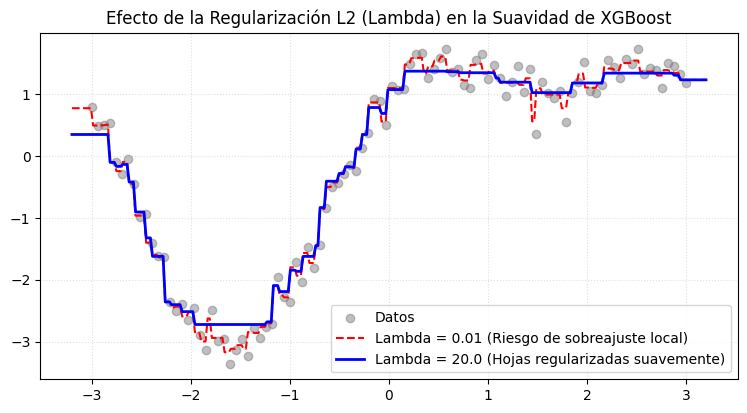

In [7]:
# Comparar efecto de lambda en el ajuste
xgb_low_reg = MiniXGBoostRegressor(n_estimators=30, learning_rate=0.2, max_depth=4, reg_lambda=0.01).fit(X_sine, y_sine)
xgb_high_reg = MiniXGBoostRegressor(n_estimators=30, learning_rate=0.2, max_depth=4, reg_lambda=20.0).fit(X_sine, y_sine)

plt.figure(figsize=(9, 4.5))
plt.scatter(X_sine, y_sine, color='gray', alpha=0.5, label='Datos')
plt.plot(X_grid, xgb_low_reg.predict(X_grid), 'r--', label='Lambda = 0.01 (Riesgo de sobreajuste local)')
plt.plot(X_grid, xgb_high_reg.predict(X_grid), 'b-', linewidth=2, label='Lambda = 20.0 (Hojas regularizadas suavemente)')
plt.title('Efecto de la Regularización L2 (Lambda) en la Suavidad de XGBoost')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.4)
plt.show()

### Reto 2 (Para resolver): Derivar Gradiente y Hessiano para Clasificación Binaria (Log Loss)
Para adaptar `MiniXGBoost` a clasificación binaria ($y \in \{0, 1\}$), la predicción del ensemble se interpreta como un logit $z = \hat{y}$, y la probabilidad es $p = \sigma(z) = rac{1}{1 + e^{-z}}$.

La pérdida de Log-Loss es:
$$\mathcal{L}(y, p) = - [y \log(p) + (1 - y) \log(1 - p)]$$

1. **Derivada de primer orden (Gradiente $g_i$):**
   $$g_i = rac{\partial \mathcal{L}}{\partial z_i} = p_i - y_i$$
2. **Derivada de segundo orden (Hessiano $h_i$):**
   $$h_i = rac{\partial^2 \mathcal{L}}{\partial z_i^2} = p_i (1 - p_i)$$

Implementa a continuación una función que calcule $g$ y $h$ para clasificación binaria:

In [8]:
# TU CÓDIGO DEL RETO 2 AQUÍ
def compute_binary_gradient_hessian(y_true: np.ndarray, logits: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Calcula g_i y h_i analíticamente para Binary Cross-Entropy en XGBoost.
    """
    # 1. Calcular probabilidades p = sigmoid(logits)
    # 2. g = p - y_true
    # 3. h = p * (1 - p)
    pass

---

## 6. 📚 Referencias Fundamentales & Lecturas Recomendadas

### 📄 Papers Seminales
1. **Chen, T., & Guestrin, C. (2016):** *"XGBoost: A Scalable Tree Boosting System"*, Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining (KDD '16), 785-794. [arXiv:1603.02754](https://arxiv.org/abs/1603.02754)
   * *¿Qué leer?* La Sección 2 ("Gradient Tree Boosting"), donde se derivan paso a paso las fórmulas de la Serie de Taylor y el Split Gain.
2. **Friedman, J. H. (2001):** *"Greedy Function Approximation: A Gradient Boosting Machine"*, Annals of Statistics, 29(5), 1189-1232. [JSTOR Link](https://www.jstor.org/stable/2699986)
   * *¿Qué leer?* La conceptualización del boosting como optimización en espacio de funciones.
3. **Breiman, L. (2001):** *"Random Forests"*, Machine Learning, 45(1), 5-32. [Springer Link](https://doi.org/10.1023/A:1010933404324)
   * *¿Qué leer?* El análisis de por qué descorrelacionar árboles mediante subespacios aleatorios de características reduce drásticamente la varianza del ensemble.
4. **Grinsztajn, L., Oyallon, E., & Varoquaux, G. (2022):** *"Why do tree-based models still outperform deep learning on typical tabular data?"*, Advances in Neural Information Processing Systems (NeurIPS 2022). [arXiv:2207.08815](https://arxiv.org/abs/2207.08815)
   * *¿Qué leer?* Excelente estudio empírico que explica por qué los sesgos inductivos de los árboles siguen reinando en tablas frente a Transformers y MLPs.